# 02 - Tests de Stationnarité et Transformations
## BTC Multivariate Forecast
### Étudiant A - Phase 1

In [1]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss

# Import des modules personnalisés
import sys
sys.path.append('..')
from src.data.features import FeatureEngineer
from src.visualization.plots import Visualizer

# Configuration
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.6f}'.format)

In [20]:
# Chargement des données
df = pd.read_csv('../data/processed/merged_dataset.csv', index_col=0, parse_dates=True)
# Nettoyage des noms de colonnes 
rename_map = { "BTC_('Close', 'BTC-USD')": "BTC_Close", "BTC_('Volume', 'BTC-USD')": "BTC_Volume", "ETH_('Close', 'ETH-USD')": "ETH_Close", "ETH_('Volume', 'ETH-USD')": "ETH_Volume", "BNB_('Close', 'BNB-USD')": "BNB_Close", "BNB_('Volume', 'BNB-USD')": "BNB_Volume", "SP500_('Close', '^GSPC')": "SP500_Close", "SP500_('Volume', '^GSPC')": "SP500_Volume", "DXY_('Close', 'DX-Y.NYB')": "DXY_Close", "DXY_('Volume', 'DX-Y.NYB')": "DXY_Volume", } 
df.rename(columns=rename_map, inplace=True)

viz = Visualizer()
fe = FeatureEngineer(config_path="../config.yaml")
print(f"Données chargées: {df.shape}")

Données chargées: (1258, 10)


## 1. Fonctions de test

In [21]:
def test_adf(series, name):
    """Test Augmented Dickey-Fuller"""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{'='*50}")
    print(f"Test ADF - {name}")
    print(f"{'='*50}")
    print(f"Statistique: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"Lags utilisés: {result[2]}")
    print(f"Observations: {result[3]}")
    print("\nValeurs critiques:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.6f}")
    
    if result[1] <= 0.05:
        print("\n✓ Série stationnaire (rejet H0)")
        return True
    else:
        print("\n✗ Série non stationnaire (non rejet H0)")
        return False

def test_kpss(series, name):
    """Test KPSS"""
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\n{'='*50}")
    print(f"Test KPSS - {name}")
    print(f"{'='*50}")
    print(f"Statistique: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"Lags: {result[2]}")
    print("\nValeurs critiques:")
    for key, value in result[3].items():
        print(f"  {key}: {value:.6f}")
    
    if result[1] >= 0.05:
        print("\n✓ Série stationnaire (non rejet H0)")
        return True
    else:
        print("\n✗ Série non stationnaire (rejet H0)")
        return False

## 2. Tests sur les prix (niveaux)

In [22]:
# Sélection des colonnes de prix
price_cols = [col for col in df.columns if 'Close' in col]

# DataFrame pour stocker les résultats
stationarity_results = []

for col in price_cols:
    print(f"\n{'#'*60}")
    print(f"# {col}")
    print(f"{'#'*60}")
    
    # ADF
    is_stationary_adf = test_adf(df[col], f"{col} - Niveau")
    
    # KPSS
    is_stationary_kpss = test_kpss(df[col], f"{col} - Niveau")
    
    # Conclusion
    if is_stationary_adf and is_stationary_kpss:
        conclusion = "Stationnaire"
    elif not is_stationary_adf and not is_stationary_kpss:
        conclusion = "Non stationnaire"
    else:
        conclusion = "Résultats contradictoires"
    
    stationarity_results.append({
        'Variable': col,
        'ADF_pvalue': adfuller(df[col].dropna())[1],
        'KPSS_pvalue': kpss(df[col].dropna(), regression='c', nlags='auto')[1],
        'Conclusion': conclusion
    })


############################################################
# BTC_Close
############################################################

Test ADF - BTC_Close - Niveau
Statistique: -1.207905
p-value: 0.670186
Lags utilisés: 22
Observations: 1235

Valeurs critiques:
  1%: -3.435656
  5%: -2.863883
  10%: -2.568018

✗ Série non stationnaire (non rejet H0)

Test KPSS - BTC_Close - Niveau
Statistique: 2.329285
p-value: 0.010000
Lags: 20

Valeurs critiques:
  10%: 0.347000
  5%: 0.463000
  2.5%: 0.574000
  1%: 0.739000

✗ Série non stationnaire (rejet H0)


C:\Users\safawardi\AppData\Local\Temp\ipykernel_13388\1824098976.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\safawardi\AppData\Local\Temp\ipykernel_13388\2672686650.py:29: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  'KPSS_pvalue': kpss(df[col].dropna(), regression='c', nlags='auto')[1],
C:\Users\safawardi\AppData\Local\Temp\ipykernel_13388\1824098976.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\safawardi\AppData\Local\Temp\ipykernel_13388\2672686650.py:29: Interpolati


############################################################
# ETH_Close
############################################################

Test ADF - ETH_Close - Niveau
Statistique: -1.892434
p-value: 0.335629
Lags utilisés: 2
Observations: 1255

Valeurs critiques:
  1%: -3.435571
  5%: -2.863846
  10%: -2.567998

✗ Série non stationnaire (non rejet H0)

Test KPSS - ETH_Close - Niveau
Statistique: 2.020834
p-value: 0.010000
Lags: 20

Valeurs critiques:
  10%: 0.347000
  5%: 0.463000
  2.5%: 0.574000
  1%: 0.739000

✗ Série non stationnaire (rejet H0)

############################################################
# BNB_Close
############################################################

Test ADF - BNB_Close - Niveau
Statistique: -1.471636
p-value: 0.547493
Lags utilisés: 19
Observations: 1238

Valeurs critiques:
  1%: -3.435643
  5%: -2.863877
  10%: -2.568014

✗ Série non stationnaire (non rejet H0)

Test KPSS - BNB_Close - Niveau
Statistique: 2.794094
p-value: 0.010000
Lags: 20

Valeurs cr

C:\Users\safawardi\AppData\Local\Temp\ipykernel_13388\2672686650.py:29: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  'KPSS_pvalue': kpss(df[col].dropna(), regression='c', nlags='auto')[1],
C:\Users\safawardi\AppData\Local\Temp\ipykernel_13388\1824098976.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\safawardi\AppData\Local\Temp\ipykernel_13388\2672686650.py:29: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  'KPSS_pvalue': kpss(df[col].dropna(), regression='c', nlags='auto')[1],


In [23]:
# Résumé
results_df = pd.DataFrame(stationarity_results)
print("\nRÉSUMÉ TESTS DE STATIONNARITÉ - PRIX")
print("="*80)
results_df


RÉSUMÉ TESTS DE STATIONNARITÉ - PRIX


,Variable,ADF_pvalue,KPSS_pvalue,Conclusion
0,BTC_Close,0.670186,0.010000,Non stationnaire
1,ETH_Close,0.335629,0.010000,Non stationnaire
2,BNB_Close,0.547493,0.010000,Non stationnaire
3,SP500_Close,0.919121,0.010000,Non stationnaire
4,DXY_Close,0.792886,0.010000,Non stationnaire


### Conclusion:
Les séries de prix sont **non stationnaires** en niveau. Une transformation est nécessaire.

## 3. Tests sur les retours

In [24]:
# Calcul des log-retours
df_returns = fe.compute_returns(df, log_returns=True)
return_cols = [col for col in df_returns.columns if 'return' in col]

# Tester la stationnarité des retours
returns_stationarity = []

for col in return_cols:
    print(f"\n{'#'*60}")
    print(f"# {col}")
    print(f"{'#'*60}")
    
    # ADF
    is_stationary = test_adf(df_returns[col].dropna(), f"{col}")
    
    returns_stationarity.append({
        'Variable': col,
        'ADF_pvalue': adfuller(df_returns[col].dropna())[1],
        'Stationnaire': is_stationary
    })


############################################################
# BTC_Close_log_return
############################################################

Test ADF - BTC_Close_log_return
Statistique: -12.730427
p-value: 0.000000
Lags utilisés: 6
Observations: 1250

Valeurs critiques:
  1%: -3.435592
  5%: -2.863855
  10%: -2.568003

✓ Série stationnaire (rejet H0)

############################################################
# ETH_Close_log_return
############################################################

Test ADF - ETH_Close_log_return
Statistique: -9.861900
p-value: 0.000000
Lags utilisés: 10
Observations: 1246

Valeurs critiques:
  1%: -3.435609
  5%: -2.863862
  10%: -2.568006

✓ Série stationnaire (rejet H0)

############################################################
# BNB_Close_log_return
############################################################

Test ADF - BNB_Close_log_return
Statistique: -10.433345
p-value: 0.000000
Lags utilisés: 9
Observations: 1247

Valeurs critiques:
  1%:

In [25]:
# Résumé retours
returns_df = pd.DataFrame(returns_stationarity)
print("\nRÉSUMÉ STATIONNARITÉ - RETOURS")
print("="*80)
returns_df


RÉSUMÉ STATIONNARITÉ - RETOURS


,Variable,ADF_pvalue,Stationnaire
0,BTC_Close_log_return,0.000000,True
1,ETH_Close_log_return,0.000000,True
2,BNB_Close_log_return,0.000000,True
3,SP500_Close_log_return,0.000000,True
4,DXY_Close_log_return,0.000000,True


### Conclusion:
Les **log-retours sont stationnaires** pour toutes les séries. C'est la transformation à utiliser pour la modélisation.

## 4. Visualisation ACF/PACF

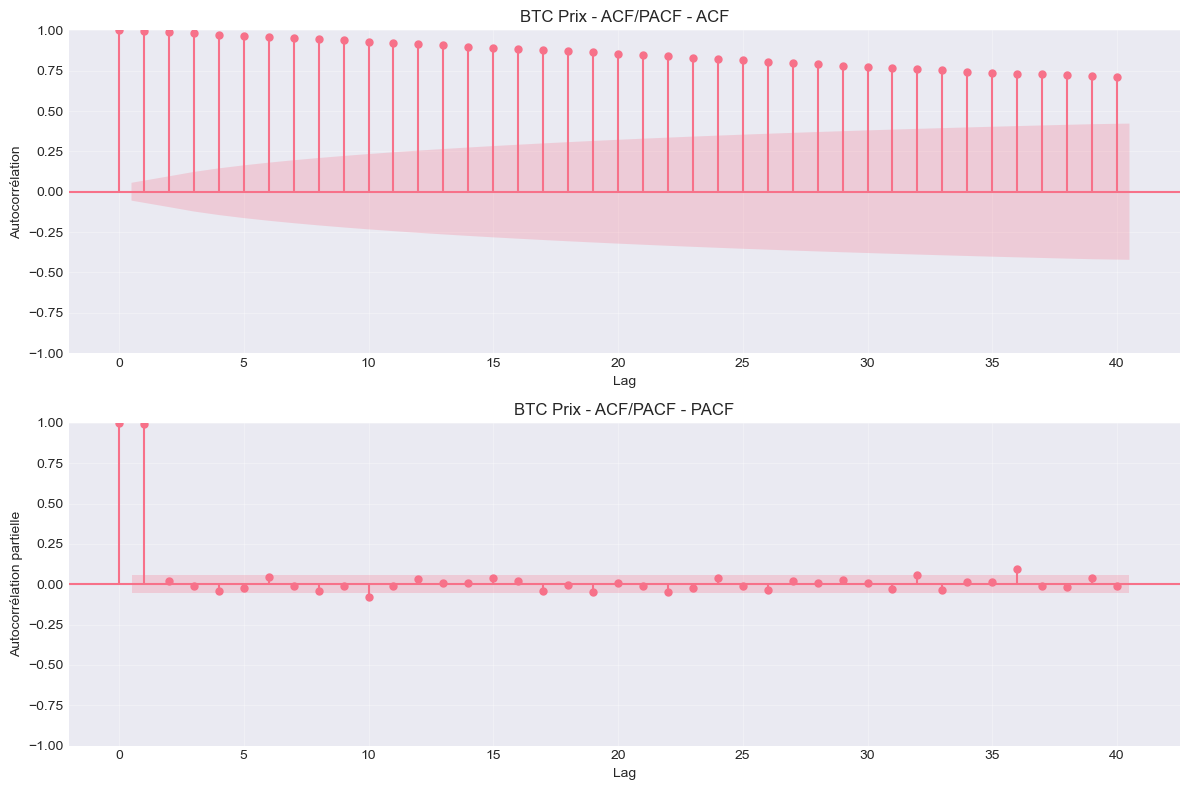

In [26]:
# ACF/PACF des prix BTC
viz.plot_acf_pacf(df['BTC_Close'], lags=40, 
                 title="BTC Prix - ACF/PACF",
                 save_path='../reports/figures/acf_pacf_btc_price.png')

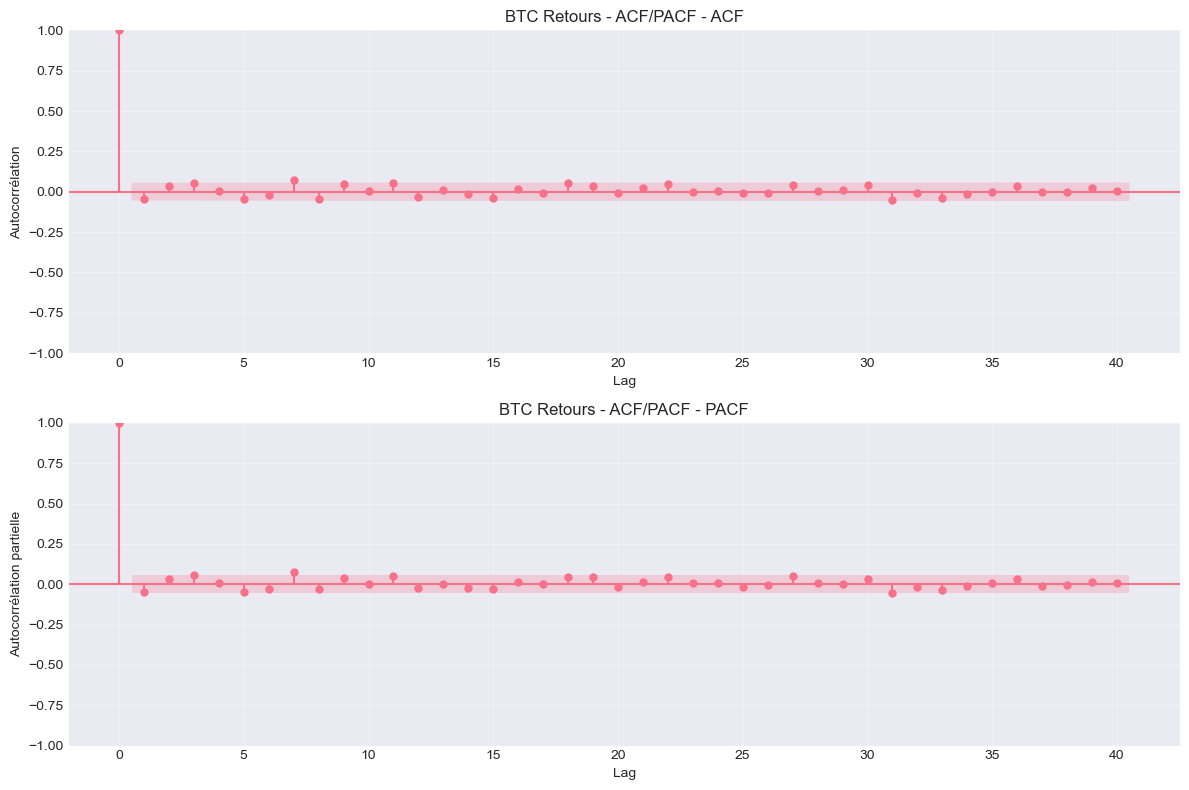

In [27]:
# ACF/PACF des retours BTC
viz.plot_acf_pacf(df_returns['BTC_Close_log_return'], lags=40,
                 title="BTC Retours - ACF/PACF",
                 save_path='../reports/figures/acf_pacf_btc_returns.png')

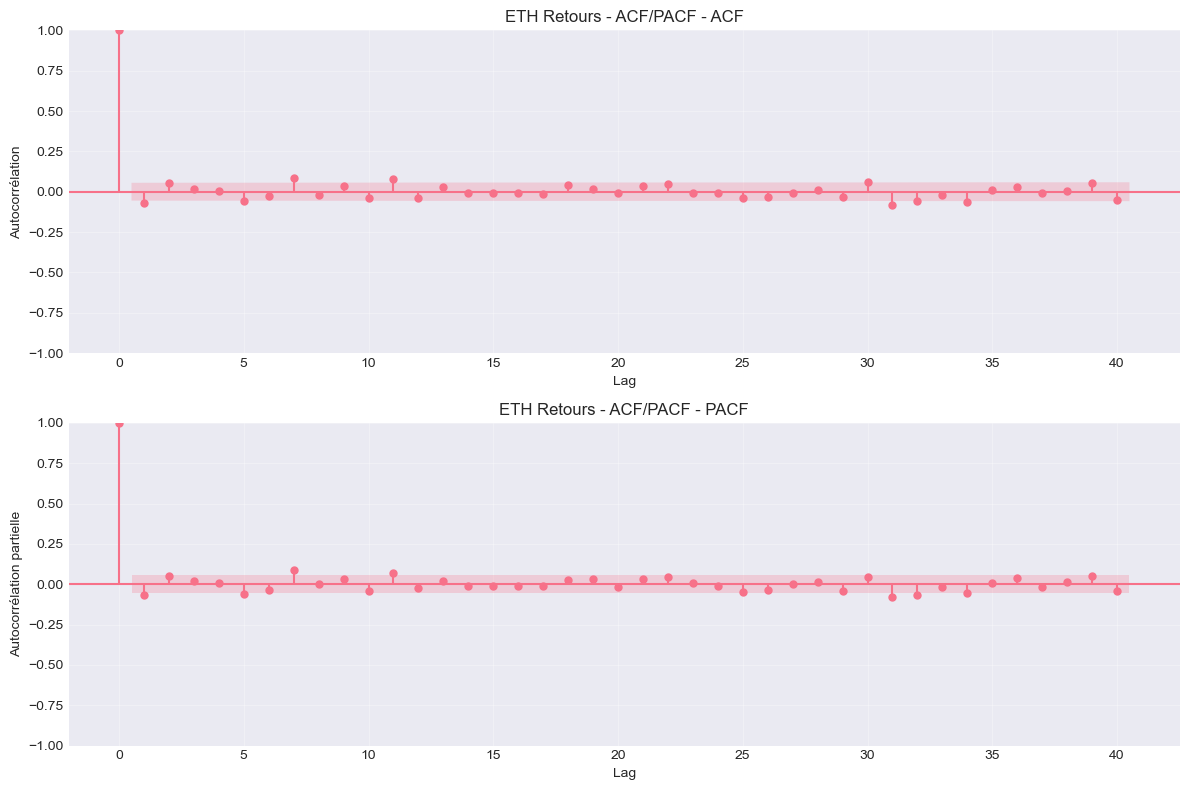

In [28]:
# ACF/PACF des retours ETH
viz.plot_acf_pacf(df_returns['ETH_Close_log_return'], lags=40,
                 title="ETH Retours - ACF/PACF")

## 5. Recommandations finales

### Décisions pour la modélisation:

1. **Transformation** : Utiliser les **log-retours** pour toutes les séries
2. **Différenciation** : Ordre 1 suffisant (d=1)
3. **Lags** : 
   - ACF des retours: coupure après lag 1-2
   - PACF des retours: décroissance exponentielle
   - Recommandation: tester lags 1 à 10
4. **Horizon H** : 1 jour (prévision à court terme)

### Variables à transmettre à Étudiant B:
- Dataset des log-retours: `df_returns`
- Prix alignés: `df`
- Conclusions des tests de stationnarité

In [29]:
# Sauvegarde des retours pour Étudiant B
df_returns.to_csv('../data/processed/returns_dataset.csv')
print("✓ Dataset des retours sauvegardé")

✓ Dataset des retours sauvegardé
